In [ ]:
!pip install opencv-python-headless
!pip install scikit-learn
!pip install efficientnet
!pip install lz4
!pip install MTCNN

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import glob
from mtcnn import MTCNN

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score,roc_auc_score, f1_score,confusion_matrix, ConfusionMatrixDisplay

from keras.applications import VGG16, ResNet50
from keras.applications.efficientnet import EfficientNetB0
from keras.applications.vgg16 import preprocess_input as preprocess_vgg
from keras.applications.resnet import preprocess_input as preprocess_resnet
from keras.applications.efficientnet import preprocess_input as preprocess_eff
from keras.models import Model

import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# paths
celeb_real_path = "/kaggle/input/celebe-real"
celeb_fake_path = "/kaggle/input/celeb-fake"
faceforensis_real_path = "/kaggle/input/faceforensis/REAL"
faceforensis_fake_deepfake = "/kaggle/input/faceforensis/FAKE-Deepfake"
faceforensis_fake_deepfakedetection = "/kaggle/input/faceforensis/FAKE-deepfakedetection"
faceforensis_fake_face2face = "/kaggle/input/faceforensis/FAKE-face2face"
faceforensis_fake_faceshifter = "/kaggle/input/faceforensis/FAKE-faceshifter"
faceforensis_fake_faceswap = "/kaggle/input/faceforensis/FAKE-faceswap"
faceforensis_fake_neuraltextures = "/kaggle/input/faceforensis/FAKE-neuraltextures"

# models
vgg_model = VGG16(weights='imagenet', include_top=False, pooling='avg')
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
eff_model = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [36]:
# MTCNN
detector = MTCNN()

def extract_face_mtcnn(image):
    faces = detector.detect_faces(image)
    if faces:
        x, y, w, h = faces[0]['box']
        face = image[y:y+h, x:x+w]
        return cv2.resize(face, (224, 224))
    return cv2.resize(image, (224, 224))

### CNN + PCA + SVM

In [46]:
def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["REAL", "FAKE"])
    plt.figure(figsize=(5, 5))
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

In [54]:
def extract_features_from_video(video_path, max_frames=5, use_mtcnn=False):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, frame_count // max_frames)

    features = []
    i = 0
    success = True
    while success and len(features) < max_frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        success, frame = cap.read()
        if not success:
            break
        if use_mtcnn:
            img = extract_face_mtcnn(frame)
        else:
            img = cv2.resize(frame, (224, 224))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_batch_vgg = preprocess_vgg(np.expand_dims(img_rgb.astype('float32'), axis=0))
        img_batch_resnet = preprocess_resnet(np.expand_dims(img_rgb.astype('float32'), axis=0))
        img_batch_eff = preprocess_eff(np.expand_dims(img_rgb.astype('float32'), axis=0))

        vgg_feat = vgg_model.predict(img_batch_vgg, verbose=0).flatten()
        res_feat = resnet_model.predict(img_batch_resnet, verbose=0).flatten()
        eff_feat = eff_model.predict(img_batch_eff, verbose=0).flatten()

        combined = np.concatenate([vgg_feat, res_feat, eff_feat])
        features.append(combined)

        i += step

    cap.release()
    if len(features) == 0:
        return None
    return np.mean(features, axis=0)

def generate_model(real_path, fake_path, use_mtcnn=False):
    # Inicializa as listas de features e labels
    X = []
    y = []
    
    # Coleta dos vídeos .mp4 (celeb-real e celeb-fake)
    for label, path in [("REAL", real_path), ("FAKE", fake_path)]:
        video_paths = sorted(glob.glob(os.path.join(path, "*.mp4")))[:100]  # Limita a 100 vídeos
        for video_path in tqdm(video_paths, desc=f"{label} (celeb dataset)"):
            feat = extract_features_from_video(video_path, use_mtcnn=use_mtcnn)
            if feat is not None:
                X.append(feat)
                y.append(0 if label == "REAL" else 1)
    
    X = np.array(X)
    y = np.array(y)
    
    print("Total samples collected:", len(X))
    
    # 4. PCA + SVM
    pca = PCA(n_components=10)
    X_pca = pca.fit_transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, stratify=y, random_state=42)
    
    svm = SVC(kernel='linear')
    svm.fit(X_train, y_train)
    
    y_pred = svm.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))

    # F1-score (macro)
    f1 = f1_score(y_test, y_pred, average='macro')
    print("F1-score (macro):", f1)
    
    # AUC
    if hasattr(svm, "decision_function"):
        y_scores = svm.decision_function(X_test)
        auc = roc_auc_score(y_test, y_scores)
        print("AUC:", auc)
    else:
        print("O modelo SVM não possui decision_function para calcular a AUC.")
        
    print("Classification Report:\n", classification_report(y_test, y_pred))

    return svm, pca

In [40]:
def generate_gradcam(model, preprocess_input, layer_name, img):
    img_tensor = preprocess_input(np.expand_dims(img.astype('float32'), axis=0))
    grad_model = Model(
        [model.inputs], 
        [model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = tf.reduce_mean(predictions)

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    heatmap = np.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()
    heatmap = cv2.resize(heatmap, (224, 224))

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(cv2.cvtColor(img, cv2.COLOR_RGB2BGR), 0.6, heatmap, 0.4, 0)
    return overlay

In [57]:
def analyze_and_visualize(video_path, model_name, pca, svm, use_mtcnn = False):
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, frame_count // 5)
    i = 0
    vgg_feats, resnet_feats, eff_feats = [], [], []
    print(f"\n📊 Modelo base para visualização: {model_name}")
    plt.figure(figsize=(15, 5))

    frame_index = 1
    while len(vgg_feats) < 5:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        success, frame = cap.read()
        if not success:
            break
        if use_mtcnn:
            img = extract_face_mtcnn(frame)
        else:
            img = cv2.resize(frame, (224, 224))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Preprocessing
        img_vgg = preprocess_vgg(np.expand_dims(img_rgb.astype('float32'), axis=0))
        img_res = preprocess_resnet(np.expand_dims(img_rgb.astype('float32'), axis=0))
        img_eff = preprocess_eff(np.expand_dims(img_rgb.astype('float32'), axis=0))

        # Feature extraction
        vgg_feat = vgg_model.predict(img_vgg, verbose=0).flatten()
        res_feat = resnet_model.predict(img_res, verbose=0).flatten()
        eff_feat = eff_model.predict(img_eff, verbose=0).flatten()

        vgg_feats.append(vgg_feat)
        resnet_feats.append(res_feat)
        eff_feats.append(eff_feat)

        # Grad-CAM (individual)
        if model_name == "VGG16":
            gradcam_result = generate_gradcam(vgg_model, preprocess_vgg, "block5_conv3", img_rgb)
        elif model_name == "ResNet50":
            gradcam_result = generate_gradcam(resnet_model, preprocess_resnet, "conv5_block3_out", img_rgb)
        elif model_name == "EfficientNetB0":
            gradcam_result = generate_gradcam(eff_model, preprocess_eff, "top_activation", img_rgb)

        # Plot
        plt.subplot(1, 5, frame_index)
        plt.imshow(gradcam_result)
        plt.axis("off")
        plt.title(f"Frame {frame_index}")
        frame_index += 1
        i += step

    cap.release()

    # Média das features de todos os modelos
    vgg_feats = np.mean(vgg_feats, axis=0)
    resnet_feats = np.mean(resnet_feats, axis=0)
    eff_feats = np.mean(eff_feats, axis=0)
    combined_feat = np.concatenate([vgg_feats, resnet_feats, eff_feats]).reshape(1, -1)

    # PCA + SVM
    combined_feat_pca = pca.transform(combined_feat)
    pred = svm.predict(combined_feat_pca)[0]
    label = "REAL" if pred == 0 else "FAKE"
    print(f"🧠 Classificação final do vídeo: {label}")

    plt.suptitle(f"Grad-CAM - {model_name} ({label})", fontsize=16)
    plt.show()

# Apply to VGG16, ResNet50 and EfficientNetB0

def analyze_video(video_path, pca, svm, use_mtcnn = False):
    analyze_and_visualize(video_path, "VGG16", pca, svm, use_mtcnn)
    analyze_and_visualize(video_path, "ResNet50", pca, svm, use_mtcnn)
    analyze_and_visualize(video_path, "EfficientNetB0", pca, svm, use_mtcnn)


In [50]:
celeb_svm, celeb_pca = generate_model(celeb_real_path, celeb_fake_path)

FAKE (celeb dataset): 100%|██████████| 50/50 [02:55<00:00,  3.51s/it]

Total samples collected: 100
Accuracy: 0.95
F1-score (macro): 0.949874686716792
AUC: 0.92
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.91      1.00      0.95        10

    accuracy                           0.95        20
   macro avg       0.95      0.95      0.95        20
weighted avg       0.95      0.95      0.95        20




📊 Modelo base para visualização: VGG16
🧠 Classificação final do vídeo: FAKE


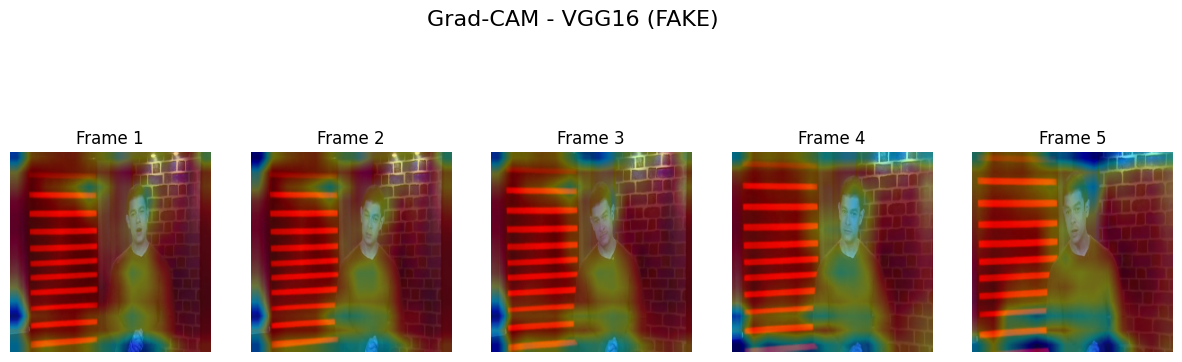


📊 Modelo base para visualização: ResNet50
🧠 Classificação final do vídeo: FAKE


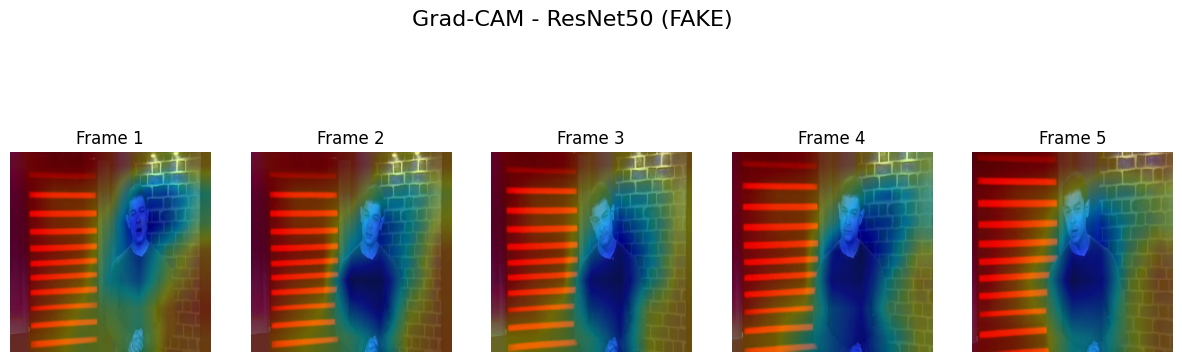


📊 Modelo base para visualização: EfficientNetB0
🧠 Classificação final do vídeo: FAKE


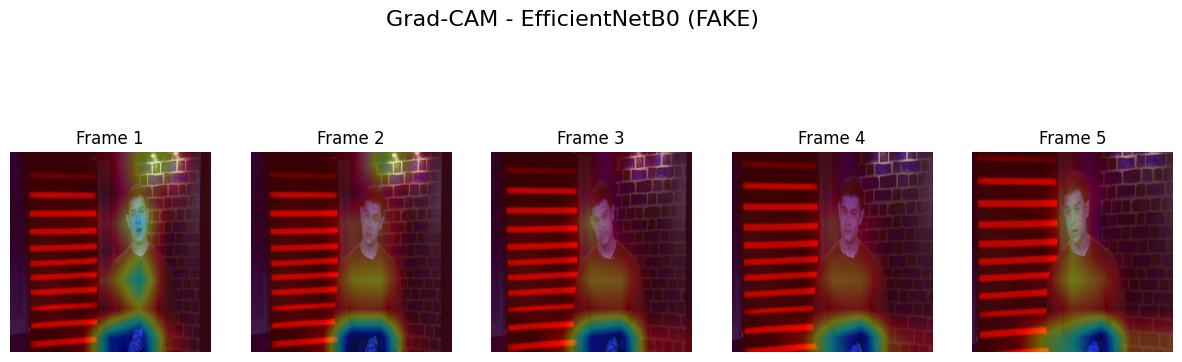

In [51]:
analyze_video("/kaggle/input/celeb-fake/id0_id1_0000.mp4", celeb_pca, celeb_svm)

In [55]:
celeb_svm_face, celeb_pca_face = generate_model(celeb_real_path, celeb_fake_path, True)

FAKE (celeb dataset): 100%|██████████| 50/50 [04:10<00:00,  5.02s/it]

Total samples collected: 100
Accuracy: 0.7
F1-score (macro): 0.7
AUC: 0.82
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.70      0.70        10
           1       0.70      0.70      0.70        10

    accuracy                           0.70        20
   macro avg       0.70      0.70      0.70        20
weighted avg       0.70      0.70      0.70        20




📊 Modelo base para visualização: VGG16
🧠 Classificação final do vídeo: REAL


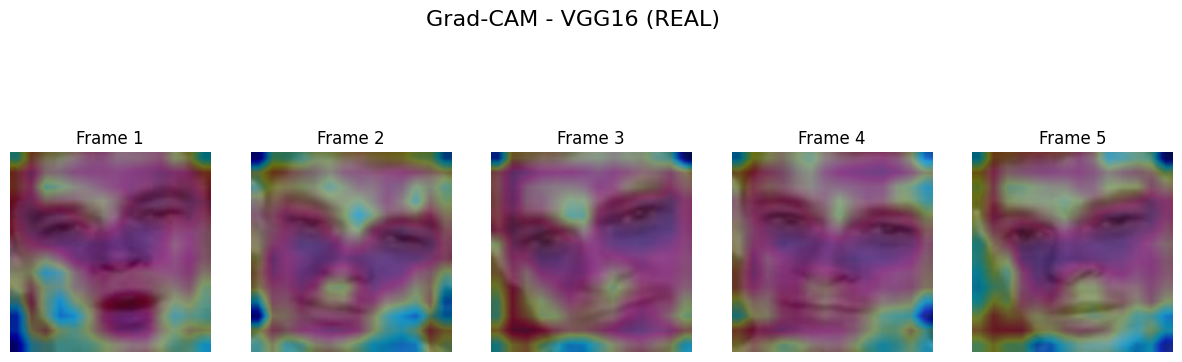


📊 Modelo base para visualização: ResNet50
🧠 Classificação final do vídeo: REAL


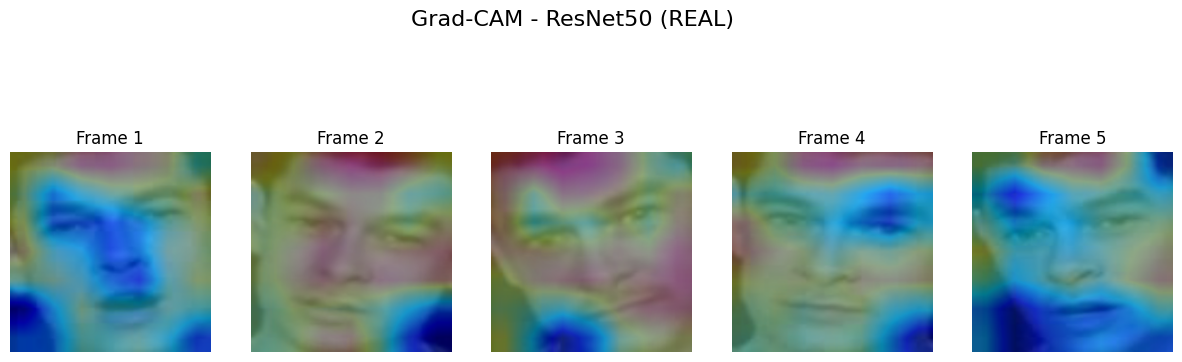


📊 Modelo base para visualização: EfficientNetB0
🧠 Classificação final do vídeo: REAL


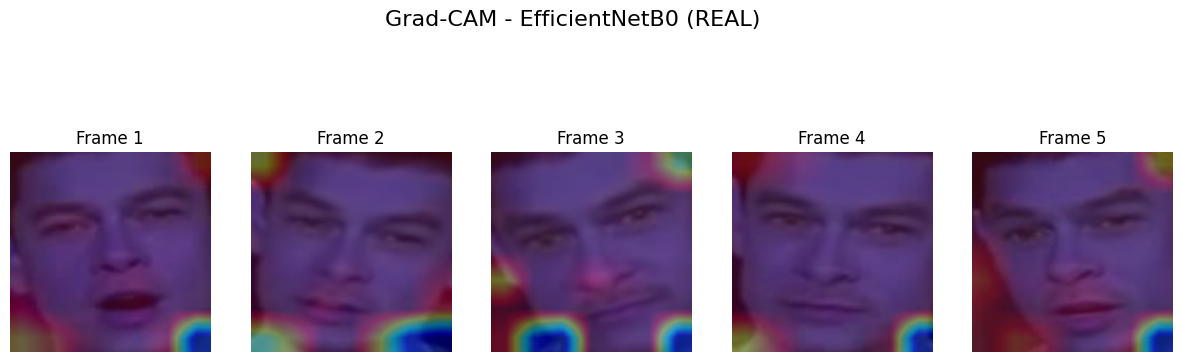

In [58]:
analyze_video("/kaggle/input/celeb-fake/id0_id1_0000.mp4", celeb_pca_face, celeb_svm_face, True)